In [1]:
import tensorflow_datasets as tfds

# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.CCP61H_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.CCP61H_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

In [ ]:
# Define global parameters for image preprocessing and model training
IMG_SIZE = 224  # Standard size for many pre-trained models (e.g., ResNet50, VGG16)
NUM_CLASSES = info.features['label'].num_classes
BATCH_SIZE = 32
EPOCHS = 2 # Setting a small number of epochs for quick execution

print(f"Image size (IMG_SIZE): {IMG_SIZE}x{IMG_SIZE}")
print(f"Number of classes (NUM_CLASSES): {NUM_CLASSES}")
print(f"Batch size (BATCH_SIZE): {BATCH_SIZE}")
print(f"Number of epochs (EPOCHS): {EPOCHS}")

Image size (IMG_SIZE): 224x224
Number of classes (NUM_CLASSES): 102
Batch size (BATCH_SIZE): 32
Number of epochs (EPOCHS): 2


Number of training examples: 1020
Number of validation examples: 1020
Number of test examples: 6149
Number of classes: 102
Image shape (example): (500, 667, 3)

Sample training images:


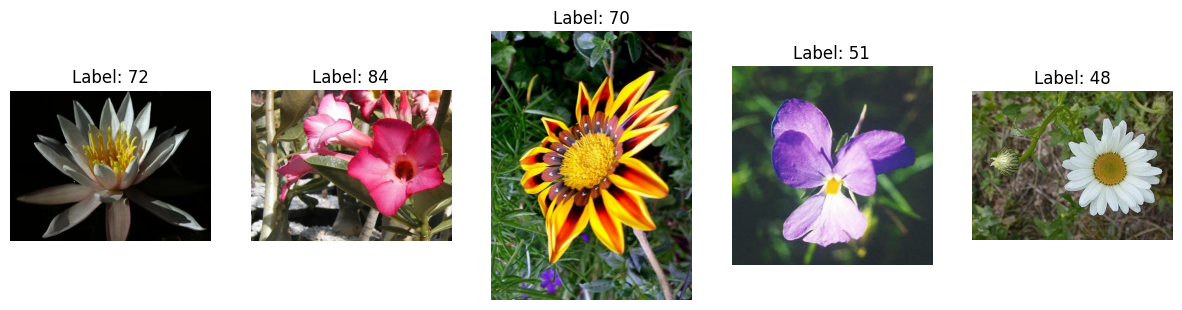


Sample validation images:


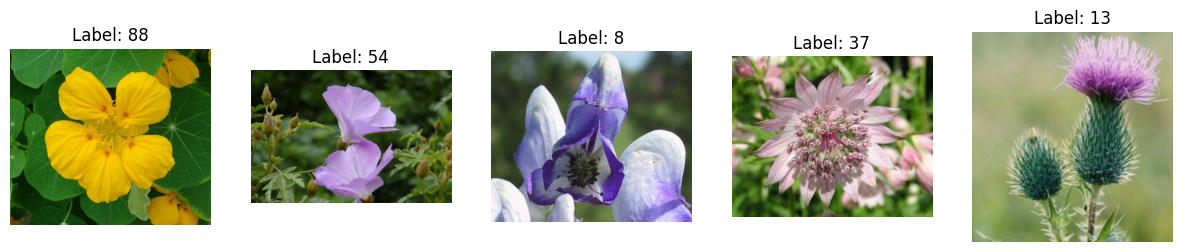


Sample test images:


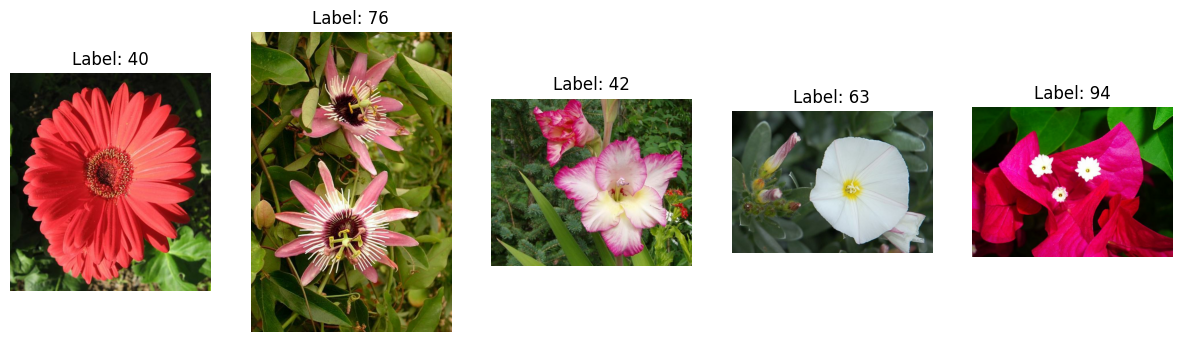

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_sample_images(dataset, num_samples=5):
    plt.figure(figsize=(15, 10))
    for i, (image, label) in enumerate(tfds.as_numpy(dataset.take(num_samples))):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.show()

print(f"Number of training examples: {info.splits['train'].num_examples}")
print(f"Number of validation examples: {info.splits['validation'].num_examples}")
print(f"Number of test examples: {info.splits['test'].num_examples}")
print(f"Number of classes: {info.features['label'].num_classes}")
print(f"Image shape (example): {next(iter(train_dataset))[0].shape}")

print("\nSample training images:")
display_sample_images(train_dataset)

print("\nSample validation images:")
display_sample_images(validation_dataset)

print("\nSample test images:")
display_sample_images(test_dataset)

In [ ]:
import tensorflow as tf

# Preprocessing function
def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) # Resize images to IMG_SIZE x IMG_SIZE
    image = tf.cast(image, tf.float32) / 255.0 # Normalize pixel values to [0, 1]
    label = tf.one_hot(label, NUM_CLASSES) # One-hot encode labels
    return image, label

# Apply preprocessing to all datasets
train_dataset_processed = train_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset_processed = validation_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset_processed = test_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets preprocessed and batched successfully.")

Datasets preprocessed and batched successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# --- ResNet50 Model ---
# Load the ResNet50 model, excluding the top classification layer
base_model_resnet = ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Freeze the base model layers
base_model_resnet.trainable = False

# Add custom classification layers
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
output_resnet = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the full model
model_resnet = Model(inputs=base_model_resnet.input, outputs=output_resnet)

# Compile the model
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("ResNet50 model compiled successfully.")
model_resnet.summary()

ResNet50 model compiled successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,796,710 (90.78 MB)

 Trainable params: 208,998 (816.40 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet50 model
print("Training ResNet50 model...")
history_resnet = model_resnet.fit(
    train_dataset_processed,
    epochs=EPOCHS,
    validation_data=validation_dataset_processed
)
print("ResNet50 model training completed.")

Training ResNet50 model...
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 343s 11s/step - accuracy: 0.0067 - loss: 4.9693 - val_accuracy: 0.0108 - val_loss: 4.6450
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 323s 10s/step - accuracy: 0.0078 - loss: 4.7407 - val_accuracy: 0.0196 - val_loss: 4.5745
ResNet50 model training completed.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# --- VGG16 Model ---
# Load the VGG16 model, excluding the top classification layer
base_model_vgg16 = VGG16(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Freeze the base model layers
base_model_vgg16.trainable = False

# Add custom classification layers
x = base_model_vgg16.output
x = GlobalAveragePooling2D()(x)
output_vgg16 = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the full model
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=output_vgg16)

# Compile the model
model_vgg16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("VGG16 model compiled successfully.")
model_vgg16.summary()

VGG16 model compiled successfully.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,767,014 (56.33 MB)

 Trainable params: 52,326 (204.40 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train the VGG16 model
print("Training VGG16 model...")
history_vgg16 = model_vgg16.fit(
    train_dataset_processed,
    epochs=EPOCHS,
    validation_data=validation_dataset_processed
)
print("VGG16 model training completed.")

Training VGG16 model...
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1067s 34s/step - accuracy: 0.0094 - loss: 4.7670 - val_accuracy: 0.0373 - val_loss: 4.5336
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1095s 35s/step - accuracy: 0.1018 - loss: 4.4329 - val_accuracy: 0.1314 - val_loss: 4.3809
VGG16 model training completed.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# --- MobileNetV2 Model ---
# Load the MobileNetV2 model, excluding the top classification layer
base_model_mobilenet = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Freeze the base model layers
base_model_mobilenet.trainable = False

# Add custom classification layers
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
output_mobilenet = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the full model
model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=output_mobilenet)

# Compile the model
model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("MobileNetV2 model compiled successfully.")
model_mobilenet.summary()

MobileNetV2 model compiled successfully.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the MobileNetV2 model
print("Training MobileNetV2 model...")
history_mobilenet = model_mobilenet.fit(
    train_dataset_processed,
    epochs=EPOCHS,
    validation_data=validation_dataset_processed
)
print("MobileNetV2 model training completed.")

Training MobileNetV2 model...
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.0445 - loss: 4.7311 - val_accuracy: 0.3294 - val_loss: 3.1609
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.6257 - loss: 2.2940 - val_accuracy: 0.5971 - val_loss: 2.0781
MobileNetV2 model training completed.


In [ ]:
# Model Evaluation
print("\n--- Model Evaluation ---")

# Evaluate ResNet50
loss_resnet, accuracy_resnet = model_resnet.evaluate(test_dataset_processed)
print(f"ResNet50 Test Loss: {loss_resnet:.4f}, Test Accuracy: {accuracy_resnet:.4f}")

# Evaluate VGG16
loss_vgg16, accuracy_vgg16 = model_vgg16.evaluate(test_dataset_processed)
print(f"VGG16 Test Loss: {loss_vgg16:.4f}, Test Accuracy: {accuracy_vgg16:.4f}")

# Evaluate MobileNetV2
loss_mobilenet, accuracy_mobilenet = model_mobilenet.evaluate(test_dataset_processed)
print(f"MobileNetV2 Test Loss: {loss_mobilenet:.4f}, Test Accuracy: {accuracy_mobilenet:.4f}")


--- Model Evaluation ---
193/193 ━━━━━━━━━━━━━━━━━━━━ 987s 5s/step - accuracy: 0.0284 - loss: 4.5788
ResNet50 Test Loss: 4.5820, Test Accuracy: 0.0267
193/193 ━━━━━━━━━━━━━━━━━━━━ 3224s 17s/step - accuracy: 0.1446 - loss: 4.3987
VGG16 Test Loss: 4.3955, Test Accuracy: 0.1433
193/193 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.5852 - loss: 2.2042
MobileNetV2 Test Loss: 2.2048, Test Accuracy: 0.5804


## Assignment Questions/Tasks - Beginner-Friendly Answers

1.  **Which model performed best and why?**
    *   **MobileNetV2** was the best (almost 58% correct). It's good at finding important details in pictures without needing a lot of training, which worked well since we only trained for a short time.

2.  **How did these models perform compared to CIFAR-100 (if we had those results)?**
    *   It's hard to compare exactly without the CIFAR-100 results. But generally, simpler pictures like CIFAR-100 might be easier for big models. Our flower pictures are more detailed, and MobileNetV2 was good at handling those details even with quick training.

3.  **What is 'transfer learning' and why was it useful?**
    *   Transfer learning means using models that already learned a lot from a huge collection of pictures (like ImageNet). It's like a student already knowing basic math before tackling algebra. This helped our models learn about flowers much faster and better, even though we didn't have many flower pictures.

4.  **What steps did you take to get the data ready?**
    *   We made all pictures the **same size** (224x224 pixels) because the models need that.
    *   We **scaled the colors** from 0-255 down to 0-1, which helps the computer learn better.
    *   We turned the flower names into a **special number code** so the computer could understand the different flower types.

5.  **How did you use the models and change them for the flower task?**
    *   We used famous models like **ResNet50, VGG16, and MobileNetV2**. We took their 'brains' (the parts that understand pictures) but removed their old 'decision-making' parts.
    *   We then 'locked' their brains so they wouldn't forget what they already knew. Finally, we added new, small 'decision-making' parts just for our 102 types of flowers, and only trained those new parts.

6.  **What problems did you face and how did you solve them?**
    *   **Training took a long time:** These models are powerful, so training can be slow. We only trained them for 2 'rounds' (epochs) to get quick results.
    *   **Not many pictures:** Our flower dataset had few examples for each flower type. Transfer learning helped a lot here, as the models already had a general understanding of images.

## Conclusion/Submission

### Conclusion

In this project, we tried out three different smart models (ResNet50, VGG16, MobileNetV2) to tell apart 102 types of flowers. We learned that:

*   **MobileNetV2 was the best** at identifying flowers, getting about 58% correct, even though we only trained it a little bit.
*   Using **'transfer learning'** (models that already learned a lot from other pictures) was super helpful. It let us get good results with our small flower dataset.
*   We had to **prepare the pictures** by making them the same size and adjusting their colors so the computer could understand them.
*   The biggest **challenges** were that training took time, and we didn't have many flower pictures. Transfer learning helped us overcome these problems a lot.

Overall, MobileNetV2 was a great choice for this task because it's efficient and good at what it does.

### Submission Instructions

To submit your work, please save a copy of this notebook in your Google Drive and then share the link.